<a href="https://colab.research.google.com/github/srishtiii28/flight_delay_predictor/blob/main/flight_delay_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Drive is mounted, you can access your files. For example, if you have a CSV file named `my_dataset.csv` in the root of your Drive, you can load it into a pandas DataFrame like this:

In [5]:
import pandas as pd

file_path = '/content/2018.csv'
# file_path = '2018.csv'

try:
  df = pd.read_csv(file_path)
  print(f"Successfully loaded data from {file_path}. Showing first 5 rows:")
  display(df.head())
except FileNotFoundError:
  print(f"Error: File not found at {file_path}. Please check the path and make sure the file exists in your Google Drive.")
except Exception as e:
  print(f"An error occurred while loading the file: {e}")

Successfully loaded data from /content/2018.csv. Showing first 5 rows:


,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,2018-01-01,UA,2429,EWR,DEN,1517,1512.0,-5.0,15.0,1527.0,...,268.0,250.0,225.0,1605.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-01,UA,2427,LAS,SFO,1115,1107.0,-8.0,11.0,1118.0,...,99.0,83.0,65.0,414.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-01,UA,2426,SNA,DEN,1335,1330.0,-5.0,15.0,1345.0,...,134.0,126.0,106.0,846.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-01,UA,2425,RSW,ORD,1546,1552.0,6.0,19.0,1611.0,...,190.0,182.0,157.0,1120.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01,UA,2424,ORD,ALB,630,650.0,20.0,13.0,703.0,...,112.0,106.0,83.0,723.0,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Fill NaN values in specific delay columns with 0
delay_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
df[delay_cols] = df[delay_cols].fillna(0)
print("Filled NaN values in delay columns with 0.")

# Fill NaN values in CANCELLATION_CODE with 'N/A'
df['CANCELLATION_CODE'] = df['CANCELLATION_CODE'].fillna('N/A')
print("Filled NaN values in 'CANCELLATION_CODE' with 'N/A'.")

# Display missing values again to see the effect of these changes
print('\nMissing values per column after filling some NaNs:')
display(df.isnull().sum())

Filled NaN values in delay columns with 0.
Filled NaN values in 'CANCELLATION_CODE' with 'N/A'.

Missing values per column after filling some NaNs:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,19320
DEP_DELAY,19932
TAXI_OUT,19627
WHEELS_OFF,19627


In [7]:
# Drop the 'Unnamed: 27' column as it's entirely empty
df = df.drop(columns=['Unnamed: 27'])
print("Dropped 'Unnamed: 27' column.")

# Convert 'FL_DATE' to datetime objects
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
print("Converted 'FL_DATE' to datetime.")

# Display info again to confirm changes
print('\nDataFrame Info after initial cleaning:')
df.info()

Dropped 'Unnamed: 27' column.
Converted 'FL_DATE' to datetime.

DataFrame Info after initial cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698218 entries, 0 to 698217
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   FL_DATE              698218 non-null  datetime64[ns]
 1   OP_CARRIER           698218 non-null  object        
 2   OP_CARRIER_FL_NUM    698218 non-null  int64         
 3   ORIGIN               698218 non-null  object        
 4   DEST                 698218 non-null  object        
 5   CRS_DEP_TIME         698218 non-null  int64         
 6   DEP_TIME             678898 non-null  float64       
 7   DEP_DELAY            678286 non-null  float64       
 8   TAXI_OUT             678591 non-null  float64       
 9   WHEELS_OFF           678591 non-null  float64       
 10  WHEELS_ON            678071 non-null  float64       
 11  TAXI_IN              678071

In [8]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698218 entries, 0 to 698217
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   FL_DATE              698218 non-null  datetime64[ns]
 1   OP_CARRIER           698218 non-null  object        
 2   OP_CARRIER_FL_NUM    698218 non-null  int64         
 3   ORIGIN               698218 non-null  object        
 4   DEST                 698218 non-null  object        
 5   CRS_DEP_TIME         698218 non-null  int64         
 6   DEP_TIME             678898 non-null  float64       
 7   DEP_DELAY            678286 non-null  float64       
 8   TAXI_OUT             678591 non-null  float64       
 9   WHEELS_OFF           678591 non-null  float64       
 10  WHEELS_ON            678071 non-null  float64       
 11  TAXI_IN              678071 non-null  float64       
 12  CRS_ARR_TIME         698217 non-null  float64       
 13

In [9]:
print('\nDataFrame Description (Numerical Columns):')
display(df.describe())


DataFrame Description (Numerical Columns):


,FL_DATE,OP_CARRIER_FL_NUM,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,698218,698218.000000,698218.000000,678898.000000,678286.000000,678591.000000,678591.000000,678071.000000,678071.000000,698217.000000,...,698217.000000,698217.000000,676953.000000,676953.000000,698217.000000,698218.000000,698218.000000,698218.000000,698218.000000,698218.000000
mean,2018-01-19 10:35:15.004769536,2566.287838,1326.434967,1332.737041,9.368154,17.904132,1359.025071,1478.957746,7.468416,1495.671659,...,0.002173,143.076780,137.040783,111.677950,793.008609,3.600599,0.808207,2.568022,0.017483,4.433896
min,2018-01-01 00:00:00,1.000000,1.000000,1.000000,-51.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,-60.000000,16.000000,8.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-01-10 00:00:00,920.000000,915.000000,921.000000,-6.000000,11.000000,939.000000,1059.000000,4.000000,1110.000000,...,0.000000,90.000000,84.000000,60.000000,356.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2018-01-19 00:00:00,2021.000000,1320.000000,1328.000000,-3.000000,15.000000,1342.000000,1513.000000,6.000000,1522.000000,...,0.000000,125.000000,119.000000,93.000000,631.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2018-01-29 00:00:00,4028.000000,1730.000000,1738.000000,6.000000,21.000000,1753.000000,1912.000000,9.000000,1919.000000,...,0.000000,174.000000,168.000000,142.000000,1028.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2018-02-08 00:00:00,7439.000000,2359.000000,2400.000000,2007.000000,177.000000,2400.000000,2400.000000,258.000000,2359.000000,...,1.000000,704.000000,728.000000,688.000000,4983.000000,2007.000000,1682.000000,1346.000000,593.000000,1648.000000
std,NaN,1883.401627,485.029112,494.974959,45.605906,10.656843,494.694307,516.890777,5.867269,509.245295,...,0.046561,73.936191,72.959458,71.152689,591.214199,28.005460,14.568100,14.634383,1.359055,22.966689


In [10]:
df_filtered = df

In [11]:
# Drop rows with remaining missing values in key columns for delay prediction
df_filtered.dropna(subset=['DEP_DELAY', 'ARR_DELAY', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME'], inplace=True)

print(f"Flights after dropping rows with remaining NaNs: {len(df_filtered)}")

# Display missing values again to confirm
print('\nMissing values per column after final NaN removal:')
display(df_filtered.isnull().sum())

Flights after dropping rows with remaining NaNs: 676110

Missing values per column after final NaN removal:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
TAXI_OUT,0
WHEELS_OFF,0


### Handling Cancelled and Diverted Flights

For a flight delay predictor, we typically want to predict the delay for flights that actually operate and arrive. Therefore, we'll remove all rows where the flight was cancelled or diverted.

In [12]:
# Before dropping, let's see how many cancelled/diverted flights we have
print(f"Total flights: {len(df)}")
print(f"Cancelled flights: {df['CANCELLED'].sum()}")
print(f"Diverted flights: {df['DIVERTED'].sum()}")

# Filter out cancelled and diverted flights
df_filtered = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

print(f"Flights after removing cancelled/diverted: {len(df_filtered)}")

# Drop the 'CANCELLED' and 'DIVERTED' columns as they are no longer needed in this filtered dataset
df_filtered = df_filtered.drop(columns=['CANCELLED', 'DIVERTED'])
print("Dropped 'CANCELLED' and 'DIVERTED' columns from the filtered DataFrame.")

# Display missing values again for the filtered DataFrame to reassess
print('\nMissing values per column after filtering out cancelled/diverted flights:')
display(df_filtered.isnull().sum())

Total flights: 676110
Cancelled flights: 0.0
Diverted flights: 0.0
Flights after removing cancelled/diverted: 676110
Dropped 'CANCELLED' and 'DIVERTED' columns from the filtered DataFrame.

Missing values per column after filtering out cancelled/diverted flights:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
TAXI_OUT,0
WHEELS_OFF,0


In [13]:
print('\nMissing values per column:')
display(df.isnull().sum())


Missing values per column:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
TAXI_OUT,0
WHEELS_OFF,0


In [14]:
print('Missing values per column in df_filtered:')
display(df_filtered.isnull().sum())

Missing values per column in df_filtered:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
TAXI_OUT,0
WHEELS_OFF,0


## train-test-split

In [15]:
df["delay"] = (df["ARR_DELAY"] > 15).astype(int)

In [16]:
features = [
    "OP_CARRIER",
    "ORIGIN",
    "DEST",
    "CRS_DEP_TIME",
    "DISTANCE",
    "CRS_ELAPSED_TIME"
]

X = df[features]
y = df["delay"]

In [17]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ["OP_CARRIER", "ORIGIN", "DEST"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

/tmp/ipykernel_6500/1627224097.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_6500/1627224097.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_6500/1627224097.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8286817233882061


In [19]:
joblib.dump(model, "model.pkl")
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [21]:
# Make predictions
y_pred = model.predict(X_test)

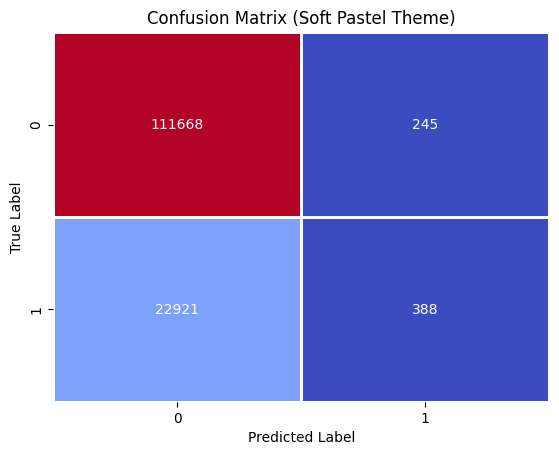

In [29]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # Generate confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Plot
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()

# plt.title("Confusion Matrix")
# plt.show()
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Custom pastel color palette
plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',  # soft gradient
    cbar=False,
    linewidths=1,
    linecolor='white'
)

plt.title("Confusion Matrix (Soft Pastel Theme)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Data Loading: Mount Google Drive

- **What it does**: This block mounts your Google Drive to the Colab environment, allowing the notebook to access files stored in your Drive.
- **Desired Output**: A message indicating that Google Drive is successfully mounted, or a prompt to authorize if not already mounted.
- **Process**: It uses the `drive.mount()` function from `google.colab` to establish a connection to your Google Drive.
- **Model Prep Step**: Data Loading (Initial Setup)

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Loading: Load Dataset

- **What it does**: This code loads the flight delay dataset from a CSV file into a pandas DataFrame.
- **Desired Output**: The first 5 rows of the loaded DataFrame to quickly inspect the data structure.
- **Process**: It uses `pandas.read_csv()` to read the specified file path. Includes error handling for `FileNotFoundError`.
- **Model Prep Step**: Data Loading

In [31]:
import pandas as pd

file_path = '/content/2018.csv'
# file_path = '2018.csv'

try:
  df = pd.read_csv(file_path)
  print(f"Successfully loaded data from {file_path}. Showing first 5 rows:")
  display(df.head())
except FileNotFoundError:
  print(f"Error: File not found at {file_path}. Please check the path and make sure the file exists in your Google Drive.")
except Exception as e:
  print(f"An error occurred while loading the file: {e}")

Successfully loaded data from /content/2018.csv. Showing first 5 rows:


,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,2018-01-01,UA,2429.0,EWR,DEN,1517.0,1512.0,-5.0,15.0,1527.0,...,268.0,250.0,225.0,1605.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-01,UA,2427.0,LAS,SFO,1115.0,1107.0,-8.0,11.0,1118.0,...,99.0,83.0,65.0,414.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-01,UA,2426.0,SNA,DEN,1335.0,1330.0,-5.0,15.0,1345.0,...,134.0,126.0,106.0,846.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-01,UA,2425.0,RSW,ORD,1546.0,1552.0,6.0,19.0,1611.0,...,190.0,182.0,157.0,1120.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01,UA,2424.0,ORD,ALB,630.0,650.0,20.0,13.0,703.0,...,112.0,106.0,83.0,723.0,NaN,NaN,NaN,NaN,NaN,NaN


### Data Cleaning: Fill Missing Values

- **What it does**: This block fills missing (NaN) values in specific delay-related columns with 0 and the `CANCELLATION_CODE` column with 'N/A'.
- **Desired Output**: Confirmation messages and an updated display of missing values per column, showing the effect of the imputation.
- **Process**: It uses the `.fillna()` method on selected DataFrame columns.
- **Model Prep Step**: Data Cleaning

In [32]:
# Fill NaN values in specific delay columns with 0
delay_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
df[delay_cols] = df[delay_cols].fillna(0)
print("Filled NaN values in delay columns with 0.")

# Fill NaN values in CANCELLATION_CODE with 'N/A'
df['CANCELLATION_CODE'] = df['CANCELLATION_CODE'].fillna('N/A')
print("Filled NaN values in 'CANCELLATION_CODE' with 'N/A'.")

# Display missing values again to see the effect of these changes
print('\nMissing values per column after filling some NaNs:')
display(df.isnull().sum())

Filled NaN values in delay columns with 0.
Filled NaN values in 'CANCELLATION_CODE' with 'N/A'.

Missing values per column after filling some NaNs:


,0
FL_DATE,0
OP_CARRIER,1
OP_CARRIER_FL_NUM,1
ORIGIN,1
DEST,1
CRS_DEP_TIME,1
DEP_TIME,109946
DEP_DELAY,114863
TAXI_OUT,113378
WHEELS_OFF,113377


### Data Cleaning: Drop Unnecessary Column and Convert Data Type

- **What it does**: Drops a column named 'Unnamed: 27' (assumed to be empty) and converts the 'FL_DATE' column to datetime objects.
- **Desired Output**: Confirmation messages and the DataFrame's info (`df.info()`) to verify the changes.
- **Process**: Uses the `df.drop()` method to remove the column and `pd.to_datetime()` to change the data type of 'FL_DATE'.
- **Model Prep Step**: Data Cleaning

In [33]:
# Drop the 'Unnamed: 27' column as it's entirely empty
df = df.drop(columns=['Unnamed: 27'])
print("Dropped 'Unnamed: 27' column.")

# Convert 'FL_DATE' to datetime objects
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
print("Converted 'FL_DATE' to datetime.")

# Display info again to confirm changes
print('\nDataFrame Info after initial cleaning:')
df.info()

Dropped 'Unnamed: 27' column.


ValueError: time data "2018-" doesn't match format "%Y-%m-%d", at position 359. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

### Data Exploration: Display DataFrame Info

- **What it does**: Provides a concise summary of the DataFrame, including data types, non-null values, and memory usage.
- **Desired Output**: A printout of the DataFrame's structure and column information.
- **Process**: Calls the `.info()` method on the DataFrame `df`.
- **Model Prep Step**: Data Exploration/Verification

In [34]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7090730 entries, 0 to 7090729
Data columns (total 27 columns):
 #   Column               Dtype  
---  ------               -----  
 0   FL_DATE              object 
 1   OP_CARRIER           object 
 2   OP_CARRIER_FL_NUM    float64
 3   ORIGIN               object 
 4   DEST                 object 
 5   CRS_DEP_TIME         float64
 6   DEP_TIME             float64
 7   DEP_DELAY            float64
 8   TAXI_OUT             float64
 9   WHEELS_OFF           float64
 10  WHEELS_ON            float64
 11  TAXI_IN              float64
 12  CRS_ARR_TIME         float64
 13  ARR_TIME             float64
 14  ARR_DELAY            float64
 15  CANCELLED            float64
 16  CANCELLATION_CODE    object 
 17  DIVERTED             float64
 18  CRS_ELAPSED_TIME     float64
 19  ACTUAL_ELAPSED_TIME  float64
 20  AIR_TIME             float64
 21  DISTANCE             float64
 22  CARRIER_DELAY        float64
 23  WEATHER_DELAY   

### Data Exploration: Display Numerical Column Description

- **What it does**: Generates descriptive statistics for all numerical columns in the DataFrame.
- **Desired Output**: A table showing count, mean, standard deviation, min, max, and quartiles for numerical features.
- **Process**: Calls the `.describe()` method on the DataFrame `df`.
- **Model Prep Step**: Data Exploration

In [35]:
print('\nDataFrame Description (Numerical Columns):')
display(df.describe())


DataFrame Description (Numerical Columns):


,OP_CARRIER_FL_NUM,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,7.090729e+06,7.090729e+06,6.980784e+06,6.975867e+06,6.977352e+06,6.977353e+06,6.974110e+06,6.974110e+06,7.090729e+06,6.974111e+06,...,7.090729e+06,7.090719e+06,6.959303e+06,6.959303e+06,7.090729e+06,7.090730e+06,7.090730e+06,7.090730e+06,7.090730e+06,7.090730e+06
mean,2.602485e+03,1.329702e+03,1.333773e+03,9.862810e+00,1.740395e+01,1.357759e+03,1.462379e+03,7.594749e+00,1.486452e+03,1.467027e+03,...,2.443472e-03,1.410092e+02,1.363704e+02,1.113851e+02,7.992116e+02,3.619677e+00,6.722576e-01,2.977512e+00,1.726353e-02,4.766417e+00
std,1.858249e+03,4.907814e+02,5.043109e+02,4.466132e+01,9.918155e+00,5.057723e+02,5.331217e+02,6.041930e+00,5.180834e+02,5.373498e+02,...,4.937107e-02,7.329354e+01,7.308685e+01,7.106317e+01,5.979073e+02,2.650694e+01,1.292683e+01,1.676242e+01,1.372551e+00,2.367260e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,-1.220000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,-9.900000e+01,1.400000e+01,7.000000e+00,3.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.025000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.320000e+02,1.044000e+03,4.000000e+00,1.100000e+03,1.049000e+03,...,0.000000e+00,8.800000e+01,8.300000e+01,6.000000e+01,3.620000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.126000e+03,1.320000e+03,1.326000e+03,-2.000000e+00,1.500000e+01,1.340000e+03,1.502000e+03,6.000000e+00,1.515000e+03,1.506000e+03,...,0.000000e+00,1.220000e+02,1.180000e+02,9.200000e+01,6.320000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.068000e+03,1.735000e+03,1.744000e+03,6.000000e+00,2.000000e+01,1.759000e+03,1.911000e+03,9.000000e+00,1.919000e+03,1.916000e+03,...,0.000000e+00,1.710000e+02,1.670000e+02,1.410000e+02,1.032000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,7.909000e+03,2.359000e+03,2.400000e+03,2.710000e+03,1.960000e+02,2.400000e+03,2.400000e+03,2.580000e+02,2.400000e+03,2.400000e+03,...,1.000000e+00,7.040000e+02,7.570000e+02,6.960000e+02,4.983000e+03,2.109000e+03,2.692000e+03,1.848000e+03,9.870000e+02,2.454000e+03


### Data Preparation: Create a Filtered DataFrame Copy

- **What it does**: Initializes a new DataFrame `df_filtered` as a copy of the original `df`. This is a preparatory step before further filtering or dropping rows.
- **Desired Output**: No direct output, but `df_filtered` will now hold a replica of `df`.
- **Process**: Simple assignment operation `df_filtered = df`.
- **Model Prep Step**: Data Preparation

In [36]:
df_filtered = df

### Data Cleaning: Drop Rows with Remaining Missing Values

- **What it does**: Removes rows from `df_filtered` where key columns for delay prediction (`DEP_DELAY`, `ARR_DELAY`, `ACTUAL_ELAPSED_TIME`, `AIR_TIME`) still contain missing values.
- **Desired Output**: A printout showing the number of flights remaining after dropping rows and an updated display of missing values per column in `df_filtered`.
- **Process**: Uses the `.dropna()` method with the `subset` parameter to specify columns and `inplace=True` to modify the DataFrame directly.
- **Model Prep Step**: Data Cleaning

In [37]:
# Drop rows with remaining missing values in key columns for delay prediction
df_filtered.dropna(subset=['DEP_DELAY', 'ARR_DELAY', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME'], inplace=True)

print(f"Flights after dropping rows with remaining NaNs: {len(df_filtered)}")

# Display missing values again to confirm
print('\nMissing values per column after final NaN removal:')
display(df_filtered.isnull().sum())

Flights after dropping rows with remaining NaNs: 6952116

Missing values per column after final NaN removal:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
TAXI_OUT,0
WHEELS_OFF,0


### Data Cleaning: Handle Cancelled and Diverted Flights

- **What it does**: Filters out cancelled and diverted flights from the `df_filtered` DataFrame, as these are typically not relevant for predicting arrival delays. It also drops the 'CANCELLED' and 'DIVERTED' columns.
- **Desired Output**: Print statements showing the count of total, cancelled, and diverted flights initially, followed by the number of flights remaining after filtering. Finally, an updated missing values count for the new `df_filtered`.
- **Process**: Uses boolean indexing to select rows where 'CANCELLED' and 'DIVERTED' are both 0, then uses `df.drop()` to remove the two columns.
- **Model Prep Step**: Data Cleaning / Feature Engineering

In [38]:
# Before dropping, let's see how many cancelled/diverted flights we have
print(f"Total flights: {len(df)}")
print(f"Cancelled flights: {df['CANCELLED'].sum()}")
print(f"Diverted flights: {df['DIVERTED'].sum()}")

# Filter out cancelled and diverted flights
df_filtered = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

print(f"Flights after removing cancelled/diverted: {len(df_filtered)}")

# Drop the 'CANCELLED' and 'DIVERTED' columns as they are no longer needed in this filtered dataset
df_filtered = df_filtered.drop(columns=['CANCELLED', 'DIVERTED'])
print("Dropped 'CANCELLED' and 'DIVERTED' columns from the filtered DataFrame.")

# Display missing values again for the filtered DataFrame to reassess
print('\nMissing values per column after filtering out cancelled/diverted flights:')
display(df_filtered.isnull().sum())

Total flights: 6952116
Cancelled flights: 0.0
Diverted flights: 0.0
Flights after removing cancelled/diverted: 6952116
Dropped 'CANCELLED' and 'DIVERTED' columns from the filtered DataFrame.

Missing values per column after filtering out cancelled/diverted flights:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
TAXI_OUT,0
WHEELS_OFF,0


### Data Verification: Display Missing Values for Original DataFrame

- **What it does**: Displays the sum of missing values for each column in the original `df` DataFrame. This is useful for comparison after cleaning steps.
- **Desired Output**: A series showing the count of null values for every column in the `df` DataFrame.
- **Process**: Calls `df.isnull().sum()`.
- **Model Prep Step**: Data Verification

In [39]:
print('\nMissing values per column:')
display(df.isnull().sum())


Missing values per column:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
TAXI_OUT,0
WHEELS_OFF,0


### Data Verification: Display Missing Values for Filtered DataFrame

- **What it does**: Displays the sum of missing values for each column in the `df_filtered` DataFrame, confirming the effect of previous cleaning and filtering steps.
- **Desired Output**: A series showing the count of null values for every column in the `df_filtered` DataFrame.
- **Process**: Calls `df_filtered.isnull().sum()`.
- **Model Prep Step**: Data Verification

In [40]:
print('Missing values per column in df_filtered:')
display(df_filtered.isnull().sum())

Missing values per column in df_filtered:


,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
TAXI_OUT,0
WHEELS_OFF,0


### Feature Engineering: Create Target Variable

- **What it does**: Creates a new binary target variable 'delay' in the DataFrame `df`. A flight is considered delayed if `ARR_DELAY` is greater than 15 minutes.
- **Desired Output**: No direct output, but the `df` DataFrame will have a new column 'delay' with 0s and 1s.
- **Process**: Applies a boolean condition (`df["ARR_DELAY"] > 15`) and converts the resulting boolean series to integers using `.astype(int)`.
- **Model Prep Step**: Feature Engineering (Target Variable Creation)

In [41]:
df["delay"] = (df["ARR_DELAY"] > 15).astype(int)

### Feature Selection: Define Features and Target

- **What it does**: Selects the relevant features (independent variables) for the model and assigns them to `X`, and assigns the target variable 'delay' to `y`.
- **Desired Output**: No direct output, but `X` will be a DataFrame containing the selected features, and `y` will be a Series containing the target variable.
- **Process**: Defines a list of feature column names and then uses DataFrame indexing to create `X` and `y`.
- **Model Prep Step**: Feature Selection

In [42]:
features = [
    "OP_CARRIER",
    "ORIGIN",
    "DEST",
    "CRS_DEP_TIME",
    "DISTANCE",
    "CRS_ELAPSED_TIME"
]

X = df[features]
y = df["delay"]

### Feature Engineering: Label Encoding Categorical Features

- **What it does**: Converts categorical features ('OP_CARRIER', 'ORIGIN', 'DEST') into numerical representations using Label Encoding. This is necessary for most machine learning algorithms.
- **Desired Output**: The `X` DataFrame with the specified categorical columns transformed into numerical labels. A dictionary `encoders` containing the fitted LabelEncoder objects for each column.
- **Process**: Iterates through a predefined list of categorical columns, initializes a `LabelEncoder` for each, fits it to the column data, and transforms the column. The fitted encoders are stored for later use (e.g., inverse transformation or new data).
- **Model Prep Step**: Feature Preprocessing

In [43]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ["OP_CARRIER", "ORIGIN", "DEST"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

/tmp/ipykernel_6500/1627224097.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_6500/1627224097.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_6500/1627224097.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

### Model Training and Evaluation: Train Random Forest Classifier

- **What it does**: Splits the dataset into training and testing sets, initializes and trains a RandomForestClassifier model, and then evaluates its accuracy on the test set.
- **Desired Output**: A printout of the model's accuracy on the test set.
- **Process**: Uses `train_test_split` from `sklearn.model_selection` to divide the data. Initializes `RandomForestClassifier` with specified hyperparameters, calls `.fit()` on the training data, and then `.score()` on the test data.
- **Model Prep Step**: Model Training and Initial Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

### Model Persistence: Save Model and Encoders

- **What it does**: Saves the trained machine learning model and the fitted LabelEncoders to disk using `joblib`. This allows the model and encoders to be reloaded and used later without retraining.
- **Desired Output**: Confirmation of the files being saved (e.g., `['model.pkl']`, `['encoders.pkl']`).
- **Process**: Uses `joblib.dump()` to serialize the `model` object and the `encoders` dictionary into '.pkl' files.
- **Model Prep Step**: Model Persistence

In [ ]:
joblib.dump(model, "model.pkl")
joblib.dump(encoders, "encoders.pkl")

### Model Evaluation: Make Predictions

- **What it does**: Uses the trained model to make predictions on the test set (`X_test`).
- **Desired Output**: No direct output, but the `y_pred` variable will be populated with the model's binary predictions (0 or 1) for the test data.
- **Process**: Calls the `predict()` method of the trained `model` with the `X_test` data.
- **Model Prep Step**: Model Evaluation

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

### Model Evaluation: Plot Confusion Matrix

- **What it does**: Generates and visualizes a confusion matrix for the model's predictions on the test set. A confusion matrix helps understand the types of errors made by the classifier.
- **Desired Output**: A heatmap plot representing the confusion matrix with annotated values.
- **Process**: Calculates the confusion matrix using `sklearn.metrics.confusion_matrix` and then uses `seaborn.heatmap` for visualization with a custom color palette.
- **Model Prep Step**: Model Evaluation

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Custom pastel color palette
plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',  # soft gradient
    cbar=False,
    linewidths=1,
    linecolor='white'
)

plt.title("Confusion Matrix (Soft Pastel Theme)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Model Evaluation: Plot Performance Metrics

- **What it does**: Calculates and plots key classification metrics: Accuracy, Precision, Recall, and F1 Score.
- **Desired Output**: A bar chart displaying the calculated values for each metric.
- **Process**: Uses `accuracy_score`, `precision_score`, `recall_score`, and `f1_score` from `sklearn.metrics` to compute the values. Then, `matplotlib.pyplot.bar` is used to visualize these metrics.
- **Model Prep Step**: Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Store in dictionary
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

# Plot
plt.figure()
plt.bar(metrics.keys(), metrics.values())
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()

### Model Evaluation: Plot ROC Curve and AUC

- **What it does**: Computes and plots the Receiver Operating Characteristic (ROC) curve and its corresponding Area Under the Curve (AUC) score. The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.
- **Desired Output**: A line plot showing the ROC curve with the calculated AUC score in the legend.
- **Process**: Obtains probability scores from the model using `model.predict_proba()`, then calculates `fpr`, `tpr`, and `roc_auc` using `roc_curve` and `auc` from `sklearn.metrics` before plotting.
- **Model Prep Step**: Model Evaluation

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Model Interpretation: Plot Feature Importance

- **What it does**: Extracts and visualizes the importance of each feature in the trained Random Forest model. This helps understand which features contribute most to the model's predictions.
- **Desired Output**: A horizontal bar chart displaying features ordered by their importance score.
- **Process**: Retrieves `feature_importances_` from the trained `model` object, creates a pandas DataFrame to organize features and their importances, sorts them, and then uses `matplotlib.pyplot.barh` for plotting.
- **Model Prep Step**: Model Interpretation

In [ ]:
import pandas as pd

# Get feature importance
importances = model.feature_importances_
feature_names = X_train.columns

# Create DataFrame
feat_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importances
    }
).sort_values(by="Importance", ascending=False)

# Plot
plt.figure()
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

### Workflow Visualization: Data Pipeline Diagram

- **What it does**: Creates a visual representation of the entire data science workflow or pipeline using Graphviz. This diagram helps in understanding the sequence of steps involved.
- **Desired Output**: A graphical directed graph (Digraph) showing the different stages of the model preparation and evaluation process.
- **Process**: Uses the `graphviz` library to define nodes (representing steps) and edges (representing transitions) to construct the pipeline diagram.
- **Model Prep Step**: Workflow Visualization / Documentation

In [ ]:
from graphviz import Digraph

dot = Digraph()

dot.node('A', 'Raw Data')
dot.node('B', 'Data Cleaning')
dot.node('C', 'Feature Engineering')
dot.node('D', 'Train-Test Split')
dot.node('E', 'Random Forest Model')
dot.node('F', 'Prediction')
dot.node('G', 'Evaluation')

dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG'])

dot

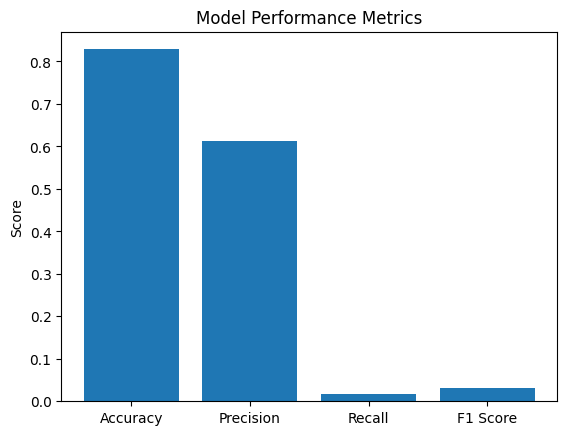

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Store in dictionary
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

# Plot
plt.figure()
plt.bar(metrics.keys(), metrics.values())
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()

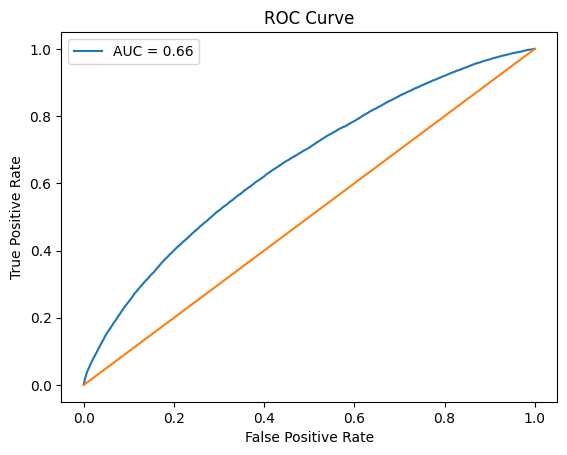

In [24]:
from sklearn.metrics import roc_curve, auc

# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

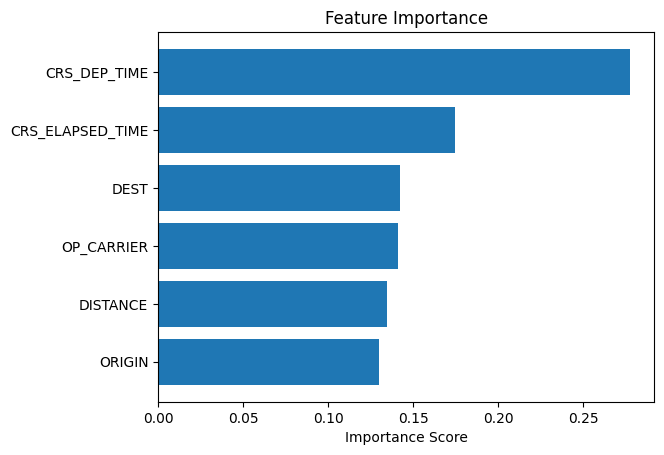

In [25]:
import pandas as pd

# Get feature importance
importances = model.feature_importances_
feature_names = X_train.columns

# Create DataFrame
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure()
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

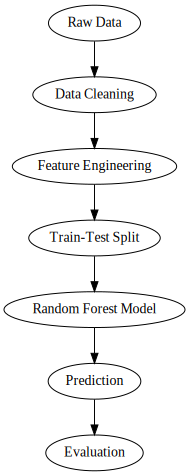

In [26]:
from graphviz import Digraph

dot = Digraph()

dot.node('A', 'Raw Data')
dot.node('B', 'Data Cleaning')
dot.node('C', 'Feature Engineering')
dot.node('D', 'Train-Test Split')
dot.node('E', 'Random Forest Model')
dot.node('F', 'Prediction')
dot.node('G', 'Evaluation')

dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG'])

dot